# Generalizability across subjects : Functional alignment with `fmralign`

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os

os.environ["NILEARN_SHARED_DATA"] = "~/shared/data/nilearn_data"

Given that we have been largely working in a predictive context, we may be interested in looking at improving the generalizability of our results, rather than just assessing them.
In neuroimaging data, _functional alignment_ is a family of techniques which aim to do exactly this by increasing the similarity of subject-level functional data.
Starting with the introduction of _hyperalignment_ {cite}`10.7554/eLife.56601`, functional alignment has evolved to include a range of methods such as Procrustes, Optimal Transport, and the Shared Response Model.

In this example we will showcase a few of these methods using the Individual Brain Charting (IBC) {cite}`Pinho2018-dm` dataset, which include a large number of different contrasts maps for 12 subjects. 
This dataset includes contrasts derived from two independent sessions, each with a different phase encoding: Antero-Posterior (AP) or Postero-Anterior (PA).
We download the images for six of the subjects:

- `imgs` is the list of paths for each subjects
- `df` is a dataframe with metadata about each of subject
- `mask` is agroup-level brain mask for IBC data

In [3]:
from fmralign.fetch_example_data import fetch_ibc_subjects_contrasts

subjects = ["sub-01", "sub-02", "sub-04", "sub-05", "sub-06", "sub-07"]
imgs, df, mask = fetch_ibc_subjects_contrasts(subjects)

[get_dataset_dir] Dataset directory found: /Users/emdupre/nilearn_data/ibc

First, let's define a region of interest (ROI) ; we will use the visual network of Yeo 2011 {cite}`Yeo2011-pl`.
We will resample this region of interest to be in the same space as our IBC subjects and then define a masker with this resampled ROI.

[fetch_atlas_yeo_2011] Dataset directory found: /Users/emdupre/nilearn_data/yeo_2011

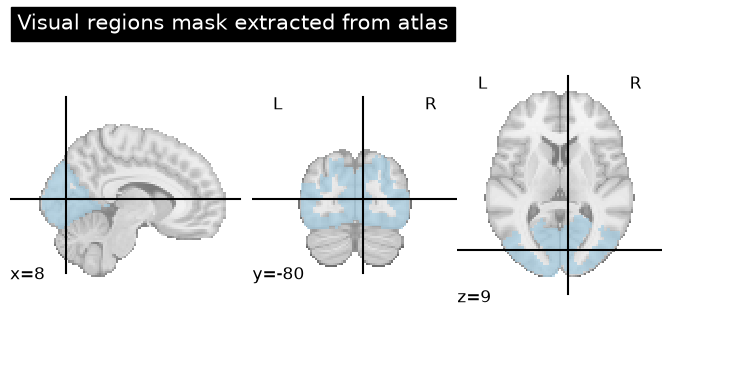

In [4]:
from nilearn import datasets
from nilearn.maskers import MultiNiftiMasker
from nilearn.image import concat_imgs, load_img, new_img_like, resample_to_img
from nilearn.plotting import plot_roi

atlas_yeo_2011 = datasets.fetch_atlas_yeo_2011()
atlas = load_img(atlas_yeo_2011.maps)

# Select visual cortex, create a mask and resample it to the right resolution

mask_visual = new_img_like(atlas, atlas.get_fdata() == 1)
resampled_mask_visual = resample_to_img(
    mask_visual, mask, interpolation="nearest"
)
roi_masker = MultiNiftiMasker(mask_img=resampled_mask_visual).fit()

# Plot the mask we will use
plot_roi(
    resampled_mask_visual,
    title="Visual regions mask extracted from atlas",
    cut_coords=(8, -80, 9),
    colorbar=True,
    cmap="Paired",
)

Using our two different phase encoding directions, we can separate out a "train" (AP) and a "test" (PA) dataset.

## Pairwise functional alignment

The first way in which we can use functional alignment is to improve similarity between two datasets, also known as "pairwise" functional alignment.

Formally, our goal is to find a minimal transformation $P$ from a source subject $s$ to a target subject $t$:

$$
  \min_{\mathbf{P}} ||\mathbf{F}^s\mathbf{P}  - \mathbf{F}^t||^2_F
$$

where $\mathbf{F}^s$ is a $n$ features ✕ $p$ voxels  matrix and $||.||_F$ denotes the Frobenius norm over matrices.
Each functional alignment methods puts different, additional constraints on the form of $\mathbf{P}$.
For example, Procrustes alignment assumes that $\mathbf{P}$ is a rotation matrix, mapping many-to-many voxels:

$$
  \min_{\mathbf{P}=s\mathbf{M}} ||\mathbf{F}^s\mathbf{P}  - \mathbf{F}^t||^2_F, s \in \mathbb{R}^{+}, \mathbf{M} \in \mathbb{R}^{p \times p}, \mathbf{M}^T\mathbf{M} = \mathbf{I}_p
$$

Within each of our training and testing datasets, we will take the first two IBC subjects, `sub-01` and `sub-02`, as our source and target subjects.

In [5]:
# The training fold, used to learn alignment from source subject toward target:
# * source train: AP contrasts for subject sub-01
# * target train: AP contrasts for subject sub-02

source_train_imgs = concat_imgs(
    df[(df.subject == "sub-01") & (df.acquisition == "ap")].path.values
)
target_train_imgs = concat_imgs(
    df[(df.subject == "sub-02") & (df.acquisition == "ap")].path.values
)

# The testing fold:
# * source test: PA contrasts for subject sub-01, used to predict
#   the corresponding contrasts of subject sub-02
# * target test: PA contrasts for subject sub-02, used as a ground truth
#   to score our predictions

source_test_imgs = concat_imgs(
    df[(df.subject == "sub-01") & (df.acquisition == "pa")].path.values
)
target_test_imgs = concat_imgs(
    df[(df.subject == "sub-02") & (df.acquisition == "pa")].path.values
)

Within the training dataset, we will learn a transformation between the source and target subject.
We can then use the same transformation in the testing dataset to assess how well we improved similarity betweeh these two subjects.

```{figure} ../images/pairwise_alignment.png
---
height: 350px
name: pairwise-alignment
---
An overview of pairwise functional alignment.
```

As mentioned previously, many different methods are available for functional alignment.
In this tutorial, we will use Procrustes, which is very fast to compute.
Calling different functional alignment methods in `fmralign` is as simple as changing the `method` argument in [the `PairwiseAlignment` estimator](https://fmralign.github.io/fmralign/modules/generated/fmralign.alignment.pairwise_alignment.PairwiseAlignment.html#fmralign.alignment.pairwise_alignment.PairwiseAlignment).

In [6]:
from fmralign import PairwiseAlignment

(
    source_train_data,
    target_train_data,
    source_test_data,
    target_test_data,
) = roi_masker.transform(
    [
        source_train_imgs,
        target_train_imgs,
        source_test_imgs,
        target_test_imgs,
    ]
)

alignment_estimator = PairwiseAlignment(method="procrustes")
alignment_estimator.fit(source_train_data, target_train_data)
target_pred_data = alignment_estimator.transform(source_test_data)

Now we can assess how well we did. Since we don't have a clear predictive or statistical learning task here on which to measure performance, we will instead assess how close the values in our `target_pred_data` are to the ground truth `target_test_data` by .

In [7]:
from nilearn import plotting
from fmralign.metrics import score_voxelwise

# Now we use this scoring function to compare the correlation of aligned and
# original data from sub-01 made with the real PA contrasts of sub-02.

baseline_score = score_voxelwise(
    target_test_data, source_test_data, loss="corr"
)
aligned_score = score_voxelwise(
    target_test_data, target_pred_data, loss="corr"
)

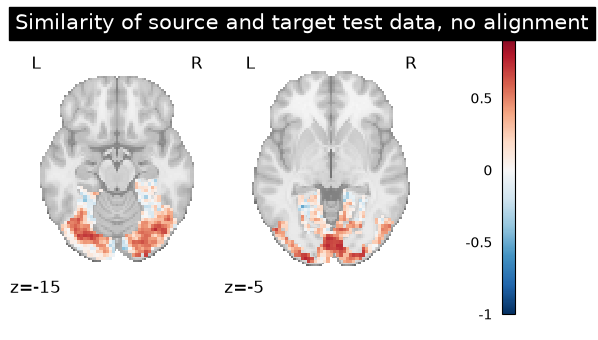

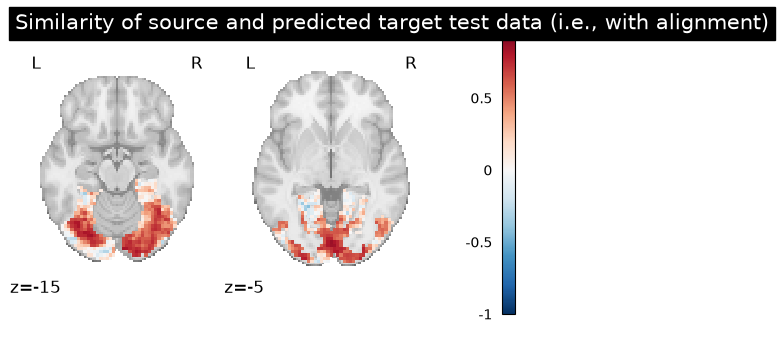

In [8]:
# And plot the results
baseline_score_img = roi_masker.inverse_transform(baseline_score)
aligned_score_img = roi_masker.inverse_transform(aligned_score)
baseline_display = plotting.plot_stat_map(
    baseline_score_img, display_mode="z", vmax=1, cut_coords=[-15, -5]
)
baseline_display.title("Similarity of source and target test data, no alignment")
display = plotting.plot_stat_map(
    aligned_score_img, display_mode="z", cut_coords=[-15, -5], vmax=1
)
display.title("Similarity of source and predicted target test data (i.e., with alignment)")

In this case, we see that Procrustes alignment significantly improved the correlation between our source subject, `sub-01`, and target subject, `sub-02` !

## Template functional alignment

What if we have more than two subjects ?
One option is to iteratively align all subjects to a given target subject, but this can be slow and difficult to interpret.
In these cases, we can also consider using "template" functional alignment.
This involves first learning a latent functional template using the training data for our source subjects.

```{figure} ../images/template_learning.png
---
height: 350px
name: template-learning
---
An overview of learning functional templates for the majority of functional alignment methods.
Note that the Shared Response Model (SRM) proceeds differently, as it involves a decomposition.
```

Formally, this template can be learned using variational inference:

$$
  \mathbf{F}^T \in \arg \min_{\mathbf{F} \in \mathbb{R}^{n \times p}} \sum_{s=1}^S ||\mathbf{F}^s\mathbf{P}^s  - \mathbf{F}||^2_F
$$

Once the template has been learned, we can use it in exactly the same framework as above, substituting $\mathbf{F}^T$ for $\mathbf{F}^t$.
To see a compairison of different functional alignment methods with the `GroupAlignment` estimator in `fmralign`, check out [this example](https://fmralign.github.io/fmralign/auto_examples/plot_alignment_methods_benchmark.html).

```{bibliography} references.bib
:style: unsrt
:filter: docname in docnames
```